# Notebook \#1:</br> Data Wrangling and Feature Engineering
#### by Sebastian Einar Salas Røkholt
---

**Notebook Index**  
- [**1 - Introduction and Notebook Setup**](#1---introduction-and-notebook-setup)  
  - [*1.1 Setup*](#11-setup)  
  - [*1.2 Explanation of variables in the dataset*](#12-explanation-of-variables-in-the-dataset)  

- [**2 - Data Wrangling**](#2---data-wrangling)  
  - [*2.1 Identifying and handling missing data*](#21-identifying-and-handling-missing-data)  
    - [*2.1.1 Handling power output readings of 0*](#211-handling-power-output-readings-of-0)  
    - [*2.1.2 Enforcing a consistent sampling rate*](#212-enforcing-a-consistent-sampling-rate)  
      - [*2.1.2.1 Identify discrepancies between expected and actual sample counts*](#2121-identify-discrepancies-between-expected-and-actual-sample-counts)  
      - [*2.1.2.2 Handling missing and extra readings*](#2122-handling-missing-and-extra-readings)  
  - [*2.2 Removing unusually short and long sessions*](#22-removing-unusually-short-and-long-sessions)  

- [**3 - Feature Engineering**](#3---feature-engineering)  
  - [*3.1 Adding temporal progress features*](#31-adding-temporal-progress-features)  
    - [*3.1.1 Converting timestamp to minutes_elapsed*](#311-converting-timestamp-to-minutes_elapsed)  
    - [*3.1.2 Adding a progress feature (log-scaled duration)*](#312-adding-a-progress-feature-log-scaled-duration)  
  - [*3.2 Relative power*](#32-relative-power)  
  - [*3.3 Adding deltas: change in power and SOC over time*](#33-adding-deltas-change-in-power-and-soc-over-time)  
  - [*3.4 EMA per session*](#34-ema-per-session)  
  - [*3.5 One-hot encoding of charger category*](#35-one-hot-encoding-of-charger-category)  
  - [*3.6 Adding temperature data*](#36-adding-temperature-data)  
  - [*3.7 Wrap-up and save dataset*](#37-wrap-up-and-save-dataset)  


---

## 1 - Introduction and Notebook Setup

In this notebook we clean the raw charging-session time series dataset so that it can be used to train a machine learning model. The tasks performed will include loading the raw data, inspecting it to identify issues, handling those issues, and engineering new features that support the models' predictive accuracy. 

### 1.1 Setup
This section initializes the computational environment by importing the required Python libraries, configuring the runtime environment and notebook settings, and defining the global constants used across the notebook.

To generate an API key for the Frost and DMI APIs, see the resources below. Both are free of charge. </br>
 - [Create a Frost user](https://frost.met.no/auth/requestCredentials.html)
 - [Register a DMI user and appliaction](https://opendatadocs.dmi.govcloud.dk/Authentication)

In [1]:
import os
import requests
import re
import pickle as pkl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from io import StringIO
from datetime import datetime, timedelta
from haversine import haversine, Unit
from dotenv import load_dotenv
from typing import List, Tuple

load_dotenv(override=True)  # Loads environment variables

# API Constants
FROST_CLIENT_ID = os.getenv("FROST_API_CLIENT_ID")  # Norway MET (Frost) client id
DMI_MET_OBS_API_KEY = os.getenv("DMI_MET_OBS_API_KEY")  # Denmark DMI API key
DMI_STATIONS_API = "https://dmigw.govcloud.dk/v2/metObs/collections/station/items"
SMHI_STATIONS_API = f"https://opendata-download-metobs.smhi.se/api/version/latest/parameter/1/station.json"  # Parameter 1 = Temperature

# Paths
RAW_PARQUET = "../Data/etron55-charging-sessions-raw-nov-24.parquet"
OUT_PARQUET = "../Data/etron55-charging-sessions.parquet"

# Configures the notebook's Pandas display settings
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

The dataset is a multivariate time series organized by electric vehicle (EV) charging sessions, where each session has been given a unique ID (`charging_id`). Within each session, the data is regularly sampled at one-minute intervals, capturing the time-dependent variables `soc`, `power` and `energy`. Additionally, sessions include variables that remain constant (static) throughout the session, such as `charger_category` and `nominal_power`. This structure aligns with the statistical definition of <a href="https://en.wikipedia.org/wiki/Panel_data">panel data</a>, as it combines cross-sectional dimensions (e.g., multiple chargers or sessions) with time-series dimensions, grouped by entities (`charging_id`). We start from the raw extract and select only the columns needed downstream.

In [2]:
# Loads the raw dataset
df = pd.read_parquet("../Data/etron55-charging-sessions-raw-nov-24.parquet")
columns = [
    "charging_id", "timestamp",
    "power", "soc", "energy",
    "charging_duration",
    "charger_category", "nominal_power",
    "lat", "lon"
]
df = df[columns].copy()
df.head()

,charging_id,timestamp,power,soc,energy,charging_duration,charger_category,nominal_power,lat,lon
0,0,2020-01-11 12:37:21,89.44,40.0,0.32,23,Ultra,150.0,59.668262,9.652725
1,0,2020-01-11 12:38:21,92.75,41.0,1.84,23,Ultra,150.0,59.668262,9.652725
2,0,2020-01-11 12:39:21,94.81,43.0,3.41,23,Ultra,150.0,59.668262,9.652725
3,0,2020-01-11 12:40:21,95.68,45.0,5.00,23,Ultra,150.0,59.668262,9.652725
4,0,2020-01-11 12:41:21,96.88,47.0,6.60,23,Ultra,150.0,59.668262,9.652725


#### Explanation of variables in the dataset
The raw dataset contains 1,643,654 measurements divided into 62,422 distinct charging sessions </br>for the Audi E-tron 55 EV. 
 - **`charging_id`, categorical, static (per session):**  The identifier for the entire charging session. A charging session is a single car, charging once at a single charging station. </br>
  - **`timestamp`, DateTime, piecewise continuous:** The date and time of each measurement (YYYY-mm-dd HH:MM:SS). The time-dependent variables are measured at one minute intervals. </br>
   - **`power`, numerical, piecewise continuous, time-dependent:** The current power output in kW from the charging station to the car. </br>
 - **`soc`, numerical, piecewise continuous, time-dependent**: The State of Charge (SOC) of the car\'s battery as a percentage </br>
 - **`energy`, numerical, piecewise continuous, time-dependent:** The aggregate power delivered to the car in kWh over the course of the charging session. </br>
  - **`charging_duration`, numerical, discrete, static (per session):** How many minutes the charging session lasted. </br>
 - **`charger_category`, categorical, static (per session):** What type of charging station is being used to provide power to the vehicle. Values are *Ultra* or *Rapid*.
 - **`nominal_power`, ordinal, static (per session):** The maximum (nominal) power output in kW for the charging station. There are 22 different values ranging from 50 to 500 kW. </br>
 - **`lat`, numerical, continuous, static (per session):** The latitude of the charging station. </br>
 - **`lon`, numerical, continuous, static (per session):** The longitude of the charging station.</br>
 <i>PS: Some of the descriptive metrics above were calculated in the <a href="https://github.com/SebastianRokholt/Machine-Teaching-for-XAI--TimeSeries-Models/blob/main/Notebooks/02__EDA.ipynb">EDA notebook</a>.</i>

----
## 2 - Data Wrangling
First, we will adresss any structural issues such as invalid values, zero-power runs, inconsistent sampling
(missing or extra readings), and implausibly short/long sessions.

In [3]:
# Displays the dataset's size, columns, number of missing values and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1643654 entries, 0 to 1643653
Data columns (total 10 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   charging_id        1643654 non-null  int64         
 1   timestamp          1643654 non-null  datetime64[ns]
 2   power              1643654 non-null  float64       
 3   soc                1643654 non-null  float64       
 4   energy             1643654 non-null  float64       
 5   charging_duration  1643654 non-null  int64         
 6   charger_category   1643654 non-null  object        
 7   nominal_power      1643654 non-null  float64       
 8   lat                1643654 non-null  float64       
 9   lon                1643654 non-null  float64       
dtypes: datetime64[ns](1), float64(6), int64(2), object(1)
memory usage: 125.4+ MB


The dataset does not contain any invalid values, such as `np.nan`, `pd.NA`, `pd.NAT`, and `None`.

In [4]:
# Sets appropriate data types
df["nominal_power"] = df["nominal_power"].astype(int)
df["charger_category"] = df["charger_category"].astype("category")

# Ensure the data are sorted by timestamp per session
df = df.sort_values(by=['charging_id', 'timestamp'])

In [5]:
print("Number of charging sessions: ", len(pd.unique(df["charging_id"])))

Number of charging sessions:  62422


### 2.1 Identifying and handling missing data
Even though the dataset doesn't contain any missing data in terms of invalid values, but there might be other types of missing data. If we look at the dataset as a collection of charging sessions (identified by `charging_id`), we see that there are: 
 - Power readings that are `0`
 - Readings at timestamps we would expect to be present, but aren't due to a inconsistent sampling rate

#### 2.1.1 Handling power output readings of `0`
We define a reading of `0` kW to be a missing value when it occurs at the beginning or the end of a charging session. These zero readings occur because the charging station starts recording data from the session before any power is delivered to the vehicle, and immediately after the the charger is disconnected. We trim these leading and trailing zeros from the dataset, as they do not contain any valid information about the normality of the charging session, and thus might introduce unwanted noise to the training data.

In [5]:
# Calculates and displays the number of rows where the power output is zero
rows_with_zeros = df[df["power"] == 0]
print(f"There are {len(rows_with_zeros)} rows where the power output is zero.")

There are 34500 rows where the power output is zero.


In [6]:
zeros_indices = rows_with_zeros.head().index  # Selects the index of five of these rows
print("First five rows with 0 in 'power' and their neighbors:\n")
for idx in zeros_indices:
    # Get two preceding and two succeeding rows
    start = max(0, idx - 2)
    end = min(len(df), idx + 3)
    neighbors = df.iloc[start:end]
    print(f"--- Rows around index {idx} ---")
    display(neighbors)

First five rows with 0 in 'power' and their neighbors:

--- Rows around index 82 ---


,charging_id,timestamp,power,soc,energy,charging_duration,charger_category,nominal_power,lat,lon
80,9323,2020-01-18 10:54:54,41.77,98.0,57.16,40,Ultra,150,59.856422,10.660129
81,9323,2020-01-18 10:55:54,34.05,98.0,57.76,40,Ultra,150,59.856422,10.660129
82,9323,2020-01-18 10:56:54,0.00,100.0,58.26,40,Ultra,150,59.856422,10.660129
83,11921,2020-01-19 19:10:14,94.05,39.0,0.23,21,Rapid,100,60.192920,5.464906
84,11921,2020-01-19 19:11:14,98.70,41.0,1.86,21,Rapid,100,60.192920,5.464906


--- Rows around index 141 ---


,charging_id,timestamp,power,soc,energy,charging_duration,charger_category,nominal_power,lat,lon
139,17906,2020-01-24 07:19:11,95.94,77.0,55.31,38,Ultra,150,60.797527,5.010914
140,17906,2020-01-24 07:20:11,95.94,79.0,56.91,38,Ultra,150,60.797527,5.010914
141,17906,2020-01-24 07:21:11,0.00,80.0,57.25,38,Ultra,150,60.797527,5.010914
142,29836,2020-01-31 20:56:55,89.13,15.0,0.22,34,Ultra,150,62.074738,9.127917
143,29836,2020-01-31 20:57:55,93.92,17.0,1.76,34,Ultra,150,62.074738,9.127917


--- Rows around index 249 ---


,charging_id,timestamp,power,soc,energy,charging_duration,charger_category,nominal_power,lat,lon
247,39929,2020-02-07 18:37:30,96.64,83.0,36.90,23,Ultra,150,60.986538,9.238304
248,39929,2020-02-07 18:38:30,91.07,85.0,38.46,23,Ultra,150,60.986538,9.238304
249,40043,2020-02-07 19:14:25,0.00,16.0,0.00,17,Rapid,50,60.739820,5.633132
250,40043,2020-02-07 19:15:25,48.98,17.0,0.67,17,Rapid,50,60.739820,5.633132
251,40043,2020-02-07 19:16:25,48.31,18.0,1.48,17,Rapid,50,60.739820,5.633132


--- Rows around index 384 ---


,charging_id,timestamp,power,soc,energy,charging_duration,charger_category,nominal_power,lat,lon
382,53363,2020-02-16 14:21:03,47.60,98.0,45.97,32,Ultra,150,60.701756,8.962077
383,53363,2020-02-16 14:22:03,35.07,98.0,46.71,32,Ultra,150,60.701756,8.962077
384,53363,2020-02-16 14:23:03,0.00,100.0,47.17,32,Ultra,150,60.701756,8.962077
385,54941,2020-02-17 15:21:01,101.34,37.0,0.28,33,Ultra,150,61.488100,6.081220
386,54941,2020-02-17 15:22:01,106.14,40.0,2.01,33,Ultra,150,61.488100,6.081220


--- Rows around index 449 ---


,charging_id,timestamp,power,soc,energy,charging_duration,charger_category,nominal_power,lat,lon
447,59415,2020-02-20 16:20:34,86.66,78.0,25.12,19,Ultra,150,58.847748,5.738282
448,59415,2020-02-20 16:21:34,86.75,79.0,26.56,19,Ultra,150,58.847748,5.738282
449,59991,2020-02-20 20:18:01,0.00,23.0,0.00,24,Rapid,50,59.668262,9.652725
450,59991,2020-02-20 20:19:01,49.20,24.0,0.68,24,Rapid,50,59.668262,9.652725
451,59991,2020-02-20 20:20:01,49.32,25.0,1.51,24,Rapid,50,59.668262,9.652725


In [7]:
def trim_zeros_from_power_output(data: pd.DataFrame) -> pd.DataFrame:
    """Trim leading and trailing zero-power rows within each session.
    
    Parameters
    ----------
    data : pd.DataFrame
        Long time-series table with at least columns: charging_id, power.
    
    Returns
    -------
    pd.DataFrame
        Same schema, with edge zeros dropped per session.
    """
    to_drop = []
    for _, g in data.groupby("charging_id"):
        vals = g["power"].values
        idx = g.index.values
        first_nonzero = next((i for i, v in enumerate(vals) if v != 0), None)
        last_nonzero = next((i for i, v in enumerate(vals[::-1]) if v != 0), None)
        if first_nonzero is None:
            # All zeros → drop whole group
            to_drop.extend(idx.tolist())
            continue
        keep = idx[first_nonzero: len(idx) - last_nonzero] if last_nonzero is not None else idx[first_nonzero:]
        drop = list(set(idx) - set(keep))
        to_drop.extend(drop)
    return data.drop(to_drop)

# Trims leading and trailing zero-power rows from the dataset
before_n = len(df)
df = trim_zeros_from_power_output(df)
print(f"Trimmed {before_n - len(df)} leading/trailing zero-power rows.")

Trimmed 33896 leading/trailing zero-power rows.


It seems that most of these zero outputs occur at the beginning (leading) or at the end (trailing) of the charging session. These zeros can be removed, but if there are zeros in the middle of a session, we want to keep them as they might be an indicator of a problem with the vehicle's battery or the charger.

In [8]:
remaining_zeros = len(df[df["power"]==0])
print(f"There are still {remaining_zeros} rows left where the power output is zero, but these values are not leading or trailing.")
df = df.copy()

There are still 604 rows left where the power output is zero, but these values are not leading or trailing.


#### 2.1.2 Enforcing a consistent sampling rate

We will ensure consistent data quality by verifying a sampling rate of one reading per minute. Grouping by charging_id, we calculate the actual and expected number of readings for each session, identifying any missing or extra readings. Additionally, we cross-check the provided `charging_duration` against the duration derived from session timestamps to flag discrepancies.

The following code performs these steps by:
1. Grouping data by charging_id to calculate session metrics like start and end times, actual readings, and reported duration.
2. Computing the expected number of readings based on timestamps and comparing them with the actual readings.
3. Identifying discrepancies in reading counts and mismatches in reported session durations.

In [9]:
def calculate_session_stats(data: pd.DataFrame) -> pd.DataFrame:
    """Compute session-level timing stats: expected vs. actual readings and duration mismatch.
    
    Returns a DataFrame with: first/last timestamps, expected_readings (minute grid),
    actual_readings (row count), n_missing_readings (= expected - actual), percentage gap,
    and a flag for mismatch vs. reported `charging_duration`.
    """
    session_stats = (
        data.groupby("charging_id")
        .agg(
            first_timestamp=("timestamp", "min"),
            last_timestamp=("timestamp", "max"),
            actual_readings=("timestamp", "count"),
            charging_duration=("charging_duration", "first"),
        )
        .reset_index()
    )
    session_stats["expected_readings"] = ((session_stats["last_timestamp"] - session_stats["first_timestamp"]).dt.total_seconds() // 60 + 1).astype(int)
    session_stats["n_missing_readings"] = session_stats["expected_readings"] - session_stats["actual_readings"]
    session_stats["extra_or_missing_percentage"] = (session_stats["n_missing_readings"] / session_stats["expected_readings"]) * 100.0
    session_stats["duration_mismatch"] = session_stats["expected_readings"] != session_stats["charging_duration"]
    return session_stats

session_stats = calculate_session_stats(df)
print("The head of the DataFrame with the calculated metrics:")
display(session_stats.head())

The head of the DataFrame with the calculated metrics:


,charging_id,first_timestamp,last_timestamp,actual_readings,charging_duration,expected_readings,n_missing_readings,extra_or_missing_percentage,duration_mismatch
0,0,2020-01-11 12:37:21,2020-01-11 12:59:21,23,23,23,0,0.0,False
1,4084,2020-01-14 12:44:11,2020-01-14 13:03:11,20,21,20,0,0.0,True
2,9323,2020-01-18 10:17:54,2020-01-18 10:55:54,39,40,39,0,0.0,True
3,11921,2020-01-19 19:10:14,2020-01-19 19:30:14,21,21,21,0,0.0,False
4,17906,2020-01-24 06:44:11,2020-01-24 07:20:11,37,38,37,0,0.0,True


In [10]:
print(f"Total number of charging sessions: {len(session_stats)}")
mismatched_sessions_count = session_stats['duration_mismatch'].sum()
print(f"Number of charging sessions with duration mismatch: {mismatched_sessions_count}")
sessions_with_missing_readings = session_stats[session_stats["n_missing_readings"] > 0]
sessions_with_extra_readings = session_stats[session_stats["n_missing_readings"] < 0]
print(f"Number of charging sessions with missing readings: {len(sessions_with_missing_readings)}")
print(f"Number of charging sessions with extra readings: {len(sessions_with_extra_readings)}")

Total number of charging sessions: 62393
Number of charging sessions with duration mismatch: 6104
Number of charging sessions with missing readings: 438
Number of charging sessions with extra readings: 960


We see that there is a large number (960) of charging sessions that have extra readings, while a smaller but significant portion (438) have missing readings. We will investigate this issue further by plotting the distribution of the number of extra and missing values. 

##### 2.1.2.1 Identify discrepancies between expected and actual sample counts
We visualize the distribution (log-y) of extra/missing readings per session, with the long tail
bucketed to keep the main part readable.

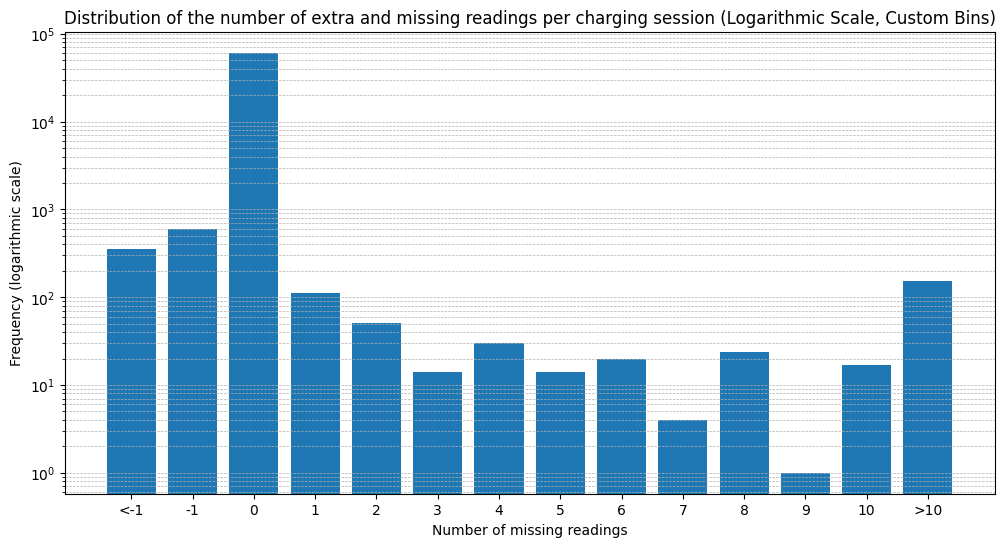

In [11]:
# Calculates the value counts of missing readings per charging session
missing_readings_counts = session_stats['n_missing_readings'].value_counts().sort_index()

# Defines custom histogram bins s.t. the counts <-1 and >10 are binned
binned_counts = {
    '<-1': missing_readings_counts[missing_readings_counts.index < -1].sum(),
    **missing_readings_counts[(missing_readings_counts.index >= -1) & (missing_readings_counts.index <= 10)].to_dict(),
    '>10': missing_readings_counts[missing_readings_counts.index > 10].sum()
}
binned_categories = [str(key) for key in binned_counts.keys()]  # Keys must be strings to avoid plotting TypeError
binned_values = list(binned_counts.values())

# Plot with logarithmic y-axis
plt.figure(figsize=(12, 6))
plt.bar(binned_categories, binned_values, log=True)
plt.title('Distribution of the number of extra and missing readings per charging session (Logarithmic Scale, Custom Bins)')
plt.xlabel('Number of missing readings')
plt.ylabel('Frequency (logarithmic scale)')
plt.grid(axis='y', which='both', linestyle='--', linewidth=0.5)
plt.show()



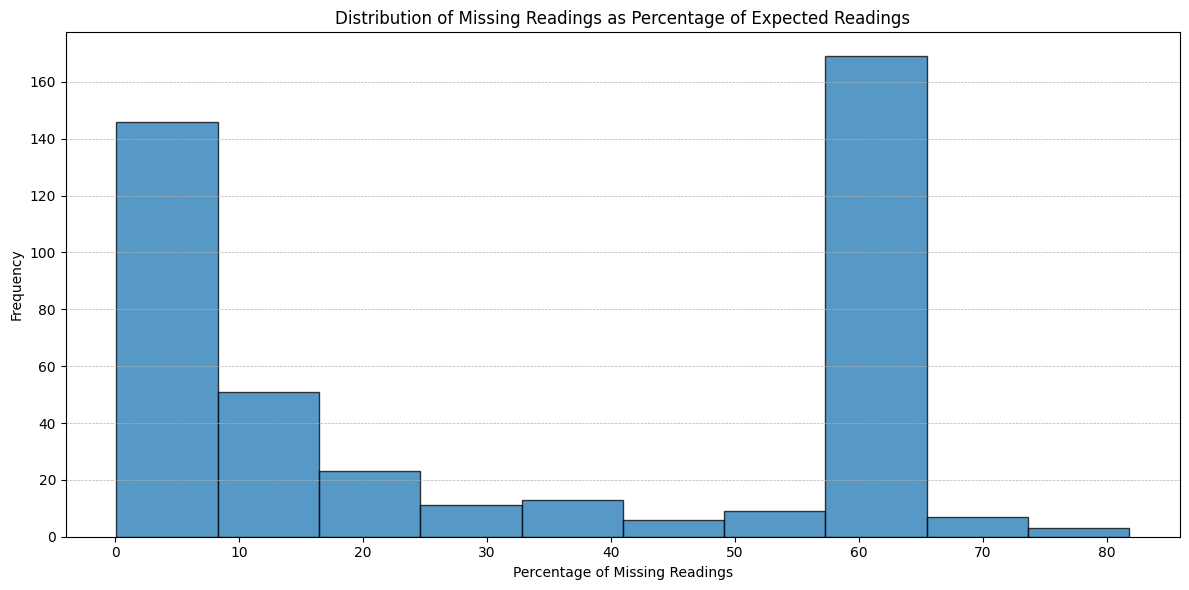

In [12]:
# Filter for sessions with missing readings (negative percentages only)
missing_readings_data = session_stats['extra_or_missing_percentage'][session_stats['extra_or_missing_percentage'] > 0]

# Define more bins for finer granularity
bins = np.linspace(0.1, missing_readings_data.max(), 11)  # 50 bins between the minimum and 0

# Plot the histogram
plt.figure(figsize=(12, 6))
plt.hist(missing_readings_data, bins=bins, alpha=0.75, edgecolor='black')
plt.title('Distribution of Missing Readings as Percentage of Expected Readings')
plt.xlabel('Percentage of Missing Readings')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

##### 2.1.2.2 Handling missing and extra readings
To handle the missing and extra readings, we will resample each session to 1 minute readings. For time-dependent numerics (`soc`, `power`, `energy`) we use mean resampling in order to "absorb" the duplicate values, followed by a linear interpolation to fill the gaps/missing values. The session level static fields (e.g. `charger_category`, `nominal_power`, `lat`, `lon`) are forward-filled so they remain constant within a session.

Charging sessions that have a large number of missing readings should be discarded, as there is no point in training a model on charging sessions that have many interpolated values. However, since the dataset contains charging sessions of variable lengths, we want to make the decision on which sessions to keep or discard based on the number of missing readings as a percentage of expected readings. Of the 1153 charging sessions that have missing readings, more than 400 of them have less than 20% missing readings. We will keep these and discard the others. 


In [13]:
# Filter sessions based on the threshold of <20% missing readings
threshold = 20
valid_sessions = session_stats[
    session_stats['extra_or_missing_percentage'] <= threshold
]['charging_id']

# Keep only valid sessions in the original dataset
df = df[df['charging_id'].isin(valid_sessions)]
n_remaining_sessions = len(df["charging_id"].unique())

print(f"Total number of charging sessions: {len(session_stats)}")
print(f"Remaining charging sessions after removing {len(session_stats) - n_remaining_sessions} "
      f"sessions with more than 20% missing readings: {n_remaining_sessions}")

Total number of charging sessions: 62393
Remaining charging sessions after removing 230 sessions with more than 20% missing readings: 62163


In [14]:
df_with_time_index = df.set_index("timestamp")

# Function to resample and a handle missing data for a single session
def resample_and_interpolate_session(session):
    """Standardize a single session to 1-min cadence and repair gaps/duplicates.
    - For numerical features `soc`, `power`, `energy`: 1‑min mean resampling, then linear interpolate.
    - For static features `charging_id`, `charging_duration`, `charger_category`, `nominal_power`, `lat`, `lon`:
      forward-fill to keep session constants stable.
    """
    numerical_resampled = session[['soc', 'power', 'energy']].resample('min').mean()
    numerical_resampled = numerical_resampled.interpolate(method='linear')
    static_resampled = session[['charging_duration', 'charger_category', 'nominal_power', 'lat', 'lon']].resample('min').ffill()
    static_resampled = static_resampled.ffill()
    resampled = pd.concat([numerical_resampled, static_resampled], axis=1)
    return resampled

# Groups by charging_id and resample each session
resampled_sessions = []
for charging_id, session in df_with_time_index.groupby('charging_id'):
    resampled_session = resample_and_interpolate_session(session)
    resampled_session['charging_id'] = charging_id  # Reintroduce the charging_id column
    resampled_sessions.append(resampled_session)

# Combines all resampled sessions into one DataFrame
resampled_df = pd.concat(resampled_sessions)
resampled_df = resampled_df.reset_index()
all_columns = ["charging_id", "timestamp", "power", "soc", "energy",\
               "charging_duration", "charger_category", "nominal_power", "lat", "lon"]
df = resampled_df[all_columns]
df.head()


,charging_id,timestamp,power,soc,energy,charging_duration,charger_category,nominal_power,lat,lon
0,0,2020-01-11 12:37:00,89.44,40.0,0.32,23.0,Ultra,150.0,59.668262,9.652725
1,0,2020-01-11 12:38:00,92.75,41.0,1.84,23.0,Ultra,150.0,59.668262,9.652725
2,0,2020-01-11 12:39:00,94.81,43.0,3.41,23.0,Ultra,150.0,59.668262,9.652725
3,0,2020-01-11 12:40:00,95.68,45.0,5.00,23.0,Ultra,150.0,59.668262,9.652725
4,0,2020-01-11 12:41:00,96.88,47.0,6.60,23.0,Ultra,150.0,59.668262,9.652725


In [15]:
df.isna().sum()

charging_id             0
timestamp               0
power                   0
soc                     0
energy                  0
charging_duration    9081
charger_category     9081
nominal_power        9081
lat                  9081
lon                  9081
dtype: int64

In [16]:
static_vars = ["charging_id", "charging_duration", "charger_category", "nominal_power", "lat", "lon"]
df[static_vars] = df[static_vars].bfill()
df.isna().sum()

charging_id          0
timestamp            0
power                0
soc                  0
energy               0
charging_duration    0
charger_category     0
nominal_power        0
lat                  0
lon                  0
dtype: int64

 ### 2.2 Removing unusually short and long sessions
Charging sessions that are very short lack sufficient temporal information for time series modeling and are disproportionately rare in the dataset. To be specific, short sessions might give a high prediction error, while long, mostly static charging sessions at low power will influence the model to predict a constant value as they contribute disproportionately to the loss calculations.

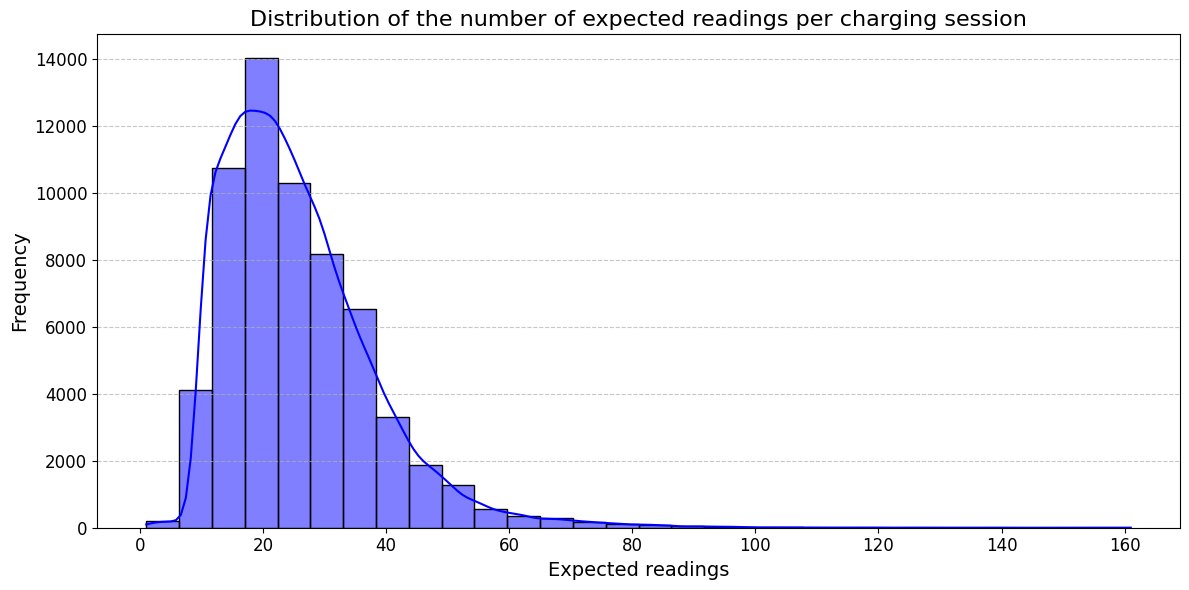

In [17]:
# Re-calculates the session statistics after handling missing data
new_session_stats = calculate_session_stats(df)

# Plots a histogram of the number of expected readings
plt.figure(figsize=(12, 6))
sns.histplot(data=new_session_stats, x='expected_readings', kde=True, bins=30, color='blue', edgecolor='black')
plt.title('Distribution of the number of expected readings per charging session', fontsize=16)
plt.xlabel('Expected readings', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

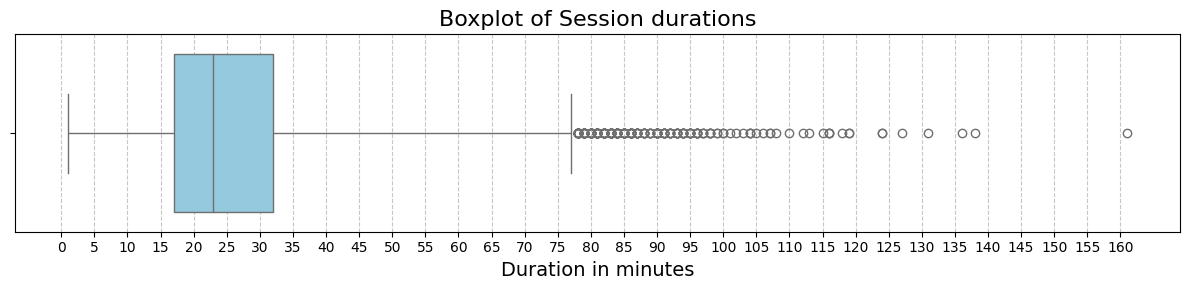

In [18]:
# Boxplot
plt.figure(figsize=(12, 3))
sns.boxplot(x=new_session_stats['expected_readings'], color='skyblue', orient='h', whis=3.0)
plt.title('Boxplot of Session durations', fontsize=16)
plt.xlabel('Duration in minutes', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.xticks(np.arange(0, session_stats['expected_readings'].max() + 1, 5), fontsize=10)
plt.show()

In [19]:
short_sessions = new_session_stats[new_session_stats["expected_readings"] < 8]
print(f"Number of charging sessions with an expected duration < 8 minutes: {len(short_sessions)}")
long_sessions = new_session_stats[new_session_stats["expected_readings"] > 60]
print(f"Number of charging sessions with an expected duration > 60 minutes: {len(long_sessions)}")


Number of charging sessions with an expected duration < 8 minutes: 229
Number of charging sessions with an expected duration > 60 minutes: 1020


#### Removing very short charging sessions

In [20]:
short_sessions_ids = short_sessions["charging_id"]
df = df[~df["charging_id"].isin(short_sessions_ids)]
print(f"Removed {len(short_sessions_ids)} short charging sessions from the dataset")

Removed 229 short charging sessions from the dataset


#### Removing very long charging sessions

In [21]:
long_sessions_ids = long_sessions["charging_id"]
df = df[~df["charging_id"].isin(long_sessions_ids)]
print(f"Removed {len(long_sessions_ids)} long charging sessions from the dataset")

Removed 1020 long charging sessions from the dataset


#### Removing the `charging_duration` variable from the dataset
It is apparent that the `charging_duration` values provided don't always match the charging session's duration between the first and the last timesteps. Going forward, we will therefore not be using this variable. 

In [22]:
df = df.drop(columns=["charging_duration"])
all_columns.remove("charging_duration")

## 3 - Feature Engineering
With a clean, consistent index we now add features that help the models learn session
dynamics; elapsed time, progress, relative power, intra-session deltas/EMAs, charger category
one-hot, and ambient temperature at session start.

### 3.1 Adding temporal progress features

#### 3.1.1 Converting `timestamp` to `minutes_elapsed`
Within each session we compute minutes since the first reading. This forms the backbone for progress-based features and makes time alignment explicit.

In [23]:
df['minutes_elapsed'] = df.groupby('charging_id')['timestamp']\
    .transform(lambda x: (x - x.min()).dt.total_seconds() // 60)
df['minutes_elapsed'] = df['minutes_elapsed'].astype(int)
df.head()

,charging_id,timestamp,power,soc,energy,charger_category,nominal_power,lat,lon,minutes_elapsed
0,0,2020-01-11 12:37:00,89.44,40.0,0.32,Ultra,150.0,59.668262,9.652725,0
1,0,2020-01-11 12:38:00,92.75,41.0,1.84,Ultra,150.0,59.668262,9.652725,1
2,0,2020-01-11 12:39:00,94.81,43.0,3.41,Ultra,150.0,59.668262,9.652725,2
3,0,2020-01-11 12:40:00,95.68,45.0,5.00,Ultra,150.0,59.668262,9.652725,3
4,0,2020-01-11 12:41:00,96.88,47.0,6.60,Ultra,150.0,59.668262,9.652725,4


#### 3.1.2 Adding a progress feature (log-scaled duration)
A compressed timeline helps the model focus early-session dynamics while not over-weighting
rare long tails. We map minutes to `[0, 1]` using a log scale and cap at 120 minutes.

In [24]:
# Progress feature (log-scaled minutes)
df["progress"] = np.log1p(df["minutes_elapsed"]) / np.log1p(120.0)
df["progress"] = np.minimum(df["progress"], 1.0)
df.head()

,charging_id,timestamp,power,soc,energy,charger_category,nominal_power,lat,lon,minutes_elapsed,progress
0,0,2020-01-11 12:37:00,89.44,40.0,0.32,Ultra,150.0,59.668262,9.652725,0,0.000000
1,0,2020-01-11 12:38:00,92.75,41.0,1.84,Ultra,150.0,59.668262,9.652725,1,0.144532
2,0,2020-01-11 12:39:00,94.81,43.0,3.41,Ultra,150.0,59.668262,9.652725,2,0.229078
3,0,2020-01-11 12:40:00,95.68,45.0,5.00,Ultra,150.0,59.668262,9.652725,3,0.289065
4,0,2020-01-11 12:41:00,96.88,47.0,6.60,Ultra,150.0,59.668262,9.652725,4,0.335594


### 3.2 Relative power
We normalize instantaneous power by the site’s nominal capacity (clipped to 120% then
rescaled to `[0,1]`).

In [25]:
denom = np.clip(df["nominal_power"].astype(float).values, 1e-6, None)
rel = (df["power"].astype(float).values / denom)
rel = np.clip(rel, 0.0, 1.2)
df["rel_power"] = rel / 1.2
df.head()

,charging_id,timestamp,power,soc,energy,charger_category,nominal_power,lat,lon,minutes_elapsed,progress,rel_power
0,0,2020-01-11 12:37:00,89.44,40.0,0.32,Ultra,150.0,59.668262,9.652725,0,0.000000,0.496889
1,0,2020-01-11 12:38:00,92.75,41.0,1.84,Ultra,150.0,59.668262,9.652725,1,0.144532,0.515278
2,0,2020-01-11 12:39:00,94.81,43.0,3.41,Ultra,150.0,59.668262,9.652725,2,0.229078,0.526722
3,0,2020-01-11 12:40:00,95.68,45.0,5.00,Ultra,150.0,59.668262,9.652725,3,0.289065,0.531556
4,0,2020-01-11 12:41:00,96.88,47.0,6.60,Ultra,150.0,59.668262,9.652725,4,0.335594,0.538222


### 3.3 Adding deltas: change in `power` and `SOC` over time
Because we want to train a residual model, we have to calculate the changes (deltas) of the target variables.

In [26]:
df["d_power"] = df.groupby("charging_id", observed=False)["power"].diff().fillna(0.0)
df["d_soc"]   = df.groupby("charging_id", observed=False)["soc"].diff().fillna(0.0)
df.head()

,charging_id,timestamp,power,soc,energy,charger_category,nominal_power,lat,lon,minutes_elapsed,progress,rel_power,d_power,d_soc
0,0,2020-01-11 12:37:00,89.44,40.0,0.32,Ultra,150.0,59.668262,9.652725,0,0.000000,0.496889,0.00,0.0
1,0,2020-01-11 12:38:00,92.75,41.0,1.84,Ultra,150.0,59.668262,9.652725,1,0.144532,0.515278,3.31,1.0
2,0,2020-01-11 12:39:00,94.81,43.0,3.41,Ultra,150.0,59.668262,9.652725,2,0.229078,0.526722,2.06,2.0
3,0,2020-01-11 12:40:00,95.68,45.0,5.00,Ultra,150.0,59.668262,9.652725,3,0.289065,0.531556,0.87,2.0
4,0,2020-01-11 12:41:00,96.88,47.0,6.60,Ultra,150.0,59.668262,9.652725,4,0.335594,0.538222,1.20,2.0


### 3.4 EMA per session
We smooth the deltas by applying a short Exponential Moving Average (span=3) within each session. We weight recent values more heavily than older ones, which helps reduce noise while retaining trend information. This in turn lowers the input variance and helps the network learn the underlying change dynamics, leading to improved generalization ability. 

In [27]:
df["d_power_ema3"] = df.groupby("charging_id", observed=False)["d_power"] \
                       .transform(lambda s: s.ewm(span=3, adjust=False).mean()).fillna(0.0)
df["d_soc_ema3"]   = df.groupby("charging_id", observed=False)["d_soc"] \
                       .transform(lambda s: s.ewm(span=3, adjust=False).mean()).fillna(0.0)
df.head()

,charging_id,timestamp,power,soc,energy,charger_category,nominal_power,lat,lon,minutes_elapsed,progress,rel_power,d_power,d_soc,d_power_ema3,d_soc_ema3
0,0,2020-01-11 12:37:00,89.44,40.0,0.32,Ultra,150.0,59.668262,9.652725,0,0.000000,0.496889,0.00,0.0,0.000000,0.0000
1,0,2020-01-11 12:38:00,92.75,41.0,1.84,Ultra,150.0,59.668262,9.652725,1,0.144532,0.515278,3.31,1.0,1.655000,0.5000
2,0,2020-01-11 12:39:00,94.81,43.0,3.41,Ultra,150.0,59.668262,9.652725,2,0.229078,0.526722,2.06,2.0,1.857500,1.2500
3,0,2020-01-11 12:40:00,95.68,45.0,5.00,Ultra,150.0,59.668262,9.652725,3,0.289065,0.531556,0.87,2.0,1.363750,1.6250
4,0,2020-01-11 12:41:00,96.88,47.0,6.60,Ultra,150.0,59.668262,9.652725,4,0.335594,0.538222,1.20,2.0,1.281875,1.8125


### 3.5 One-hot encoding of charger category
We derive a coarse charger category from `nominal_power` bins (low/mid/high) and one‑hot it as a numerical value.

In [28]:
bins   = [0, 75, 200, np.inf]
labels = ["low", "mid", "high"]
ohe_src = pd.cut(df["nominal_power"].astype(float), bins=bins, labels=labels, include_lowest=True, right=True)
ohe = pd.get_dummies(ohe_src, prefix="charger_cat", dtype=np.float32)

# Ensure all columns present
for col in ["charger_cat_low","charger_cat_mid","charger_cat_high"]:
    if col not in ohe.columns:
        ohe[col] = 0.0
ohe = ohe[["charger_cat_low","charger_cat_mid","charger_cat_high"]]

df = pd.concat([df.drop(columns=[]), ohe], axis=1)
df.head()

,charging_id,timestamp,power,soc,energy,charger_category,nominal_power,lat,lon,minutes_elapsed,progress,rel_power,d_power,d_soc,d_power_ema3,d_soc_ema3,charger_cat_low,charger_cat_mid,charger_cat_high
0,0,2020-01-11 12:37:00,89.44,40.0,0.32,Ultra,150.0,59.668262,9.652725,0,0.000000,0.496889,0.00,0.0,0.000000,0.0000,0.0,1.0,0.0
1,0,2020-01-11 12:38:00,92.75,41.0,1.84,Ultra,150.0,59.668262,9.652725,1,0.144532,0.515278,3.31,1.0,1.655000,0.5000,0.0,1.0,0.0
2,0,2020-01-11 12:39:00,94.81,43.0,3.41,Ultra,150.0,59.668262,9.652725,2,0.229078,0.526722,2.06,2.0,1.857500,1.2500,0.0,1.0,0.0
3,0,2020-01-11 12:40:00,95.68,45.0,5.00,Ultra,150.0,59.668262,9.652725,3,0.289065,0.531556,0.87,2.0,1.363750,1.6250,0.0,1.0,0.0
4,0,2020-01-11 12:41:00,96.88,47.0,6.60,Ultra,150.0,59.668262,9.652725,4,0.335594,0.538222,1.20,2.0,1.281875,1.8125,0.0,1.0,0.0


### 3.6 Adding temperature data
We use the provided location (latitute and longitude) of each charging station and time of charge to attach ambient temperature at **session start** from the nearest weather station.

Approach: find the nearest station with appropriate hourly data in Norway (Met/Frost),
Sweden (SMHI), or Denmark (DMI), download the time series for the session window, and
merge temperature at the closest timestamp to session start.

*Note:* This section uses API keys from `.env` and accesses public met APIs.
See the *Setup* section for more details.

A location given with latitude and longitude with 6 decimal places is accurate down to a radius of 11 cm, so 2 decimal places (accurate down to 1.1km) is more than accurate enough for the purpose of retrieving a temperature reading from the nearest weather station.

In [29]:
df["lat"] = df["lat"].round(2)
df["lon"] = df["lon"].round(2)

In [30]:
# Converts the timestamp to the Frost-specified format, with granularity of 1 hour
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['timestamp_H'] = df.groupby('charging_id')['timestamp'].transform('first')
df['timestamp_H'] = df['timestamp_H'].dt.strftime('%Y-%m-%dT%H')
df['timestamp_d'] = df.groupby('charging_id')['timestamp'].transform('first')
df['timestamp_d'] = df['timestamp_d'].dt.strftime('%Y-%m-%d')
df.head()

,charging_id,timestamp,power,soc,energy,charger_category,nominal_power,lat,lon,minutes_elapsed,progress,rel_power,d_power,d_soc,d_power_ema3,d_soc_ema3,charger_cat_low,charger_cat_mid,charger_cat_high,timestamp_H,timestamp_d
0,0,2020-01-11 12:37:00,89.44,40.0,0.32,Ultra,150.0,59.67,9.65,0,0.000000,0.496889,0.00,0.0,0.000000,0.0000,0.0,1.0,0.0,2020-01-11T12,2020-01-11
1,0,2020-01-11 12:38:00,92.75,41.0,1.84,Ultra,150.0,59.67,9.65,1,0.144532,0.515278,3.31,1.0,1.655000,0.5000,0.0,1.0,0.0,2020-01-11T12,2020-01-11
2,0,2020-01-11 12:39:00,94.81,43.0,3.41,Ultra,150.0,59.67,9.65,2,0.229078,0.526722,2.06,2.0,1.857500,1.2500,0.0,1.0,0.0,2020-01-11T12,2020-01-11
3,0,2020-01-11 12:40:00,95.68,45.0,5.00,Ultra,150.0,59.67,9.65,3,0.289065,0.531556,0.87,2.0,1.363750,1.6250,0.0,1.0,0.0,2020-01-11T12,2020-01-11
4,0,2020-01-11 12:41:00,96.88,47.0,6.60,Ultra,150.0,59.67,9.65,4,0.335594,0.538222,1.20,2.0,1.281875,1.8125,0.0,1.0,0.0,2020-01-11T12,2020-01-11


In [31]:
def calc_coll_period_per_location(df: pd.DataFrame) -> pd.DataFrame:
    # Get unique location-timestamp combinations, with time granularity per hour
    locations_timestamps_per_hour_df = df[["lat", "lon", "timestamp_d"]].drop_duplicates().sort_values(by=['lat', 'lon']).reset_index(drop=True)
    locations_grouped = locations_timestamps_per_hour_df.groupby(["lat", "lon"])
    # Calculate the data collection period per location
    locations_w_coll_periods = locations_grouped.agg(
        period_start=('timestamp_d', 'min'),
        period_end=('timestamp_d', 'max')
    ).reset_index()
    return locations_w_coll_periods

In [32]:
def NO_station_has_hourly_data(station_id: str, collection_period: str) -> bool:
    response = requests.get('https://frost.met.no/observations/availableTimeSeries/v0.jsonld',
        params={
            'sources': {station_id},
            'referencetime': collection_period, 
            'elements': 'air_temperature', 
            'timeresolutions': 'PT1H',
        },
        auth=(FROST_CLIENT_ID, '')
    )
    if response.status_code == 200:
        return True
    else:
        return False
    

def get_nearest_station(lat: float, lon: float, period_start: str, period_end: str, k=30) -> str:
    """Retrieves the station IDs of the k nearest weather stations 
    from a fixed point via MET Norway's Frost API. We retrieve the ids for multiple stations in case
    the <k nearest are new and we get an error when fetching the historical temperature from the Frost API later. 

    Args:
        latitude (float): The latitude
        longitude (float): The longitude
        api_client_id (str): The client ID for the Frost API. 
                             An ID can be created for free here: https://frost.met.no/auth/requestCredentials.html
        k (int, optional): The number of station IDs to check. Defaults to 30.

    Returns:
        List[str]: A list of IDs of the nearest weather stations, sorted (increasingly) by distance.
    """
    collection_period = f"{period_start}/{period_end}"
    response = requests.get('https://frost.met.no/sources/v0.jsonld',
        params={
            'geometry': f'nearest(POINT({lon} {lat}))',  # FROST API uses WKT specification, which requires lon, lat ordering
            'nearestmaxcount': k,
            'validtime': collection_period, 
            'elements': 'air_temperature'  # Filter by stations that collected temperature data
        },
        auth=(FROST_CLIENT_ID, '')
    )
    if response.status_code in [404, 412]:
        print(f"Could not find any weather stations for location with lat: {lat}, lon: {lon} \
            in time period {collection_period}")
        return np.nan, np.nan, np.nan
    else: 
        for station_metadata in response.json()["data"]:
            try:
                country = station_metadata["country"].lower()
                if country == "norge":
                    station_id, distance = station_metadata["id"], round(station_metadata["distance"], 1)
                    if NO_station_has_hourly_data(station_id, collection_period):
                        return country, station_id, distance
                    else:
                        continue

                elif country == "sverige":
                    station_id, distance = get_nearest_SE_station(lat, lon, period_start, period_end)
                    return country, station_id, distance
                elif country == "danmark":
                    station_id, distance = get_nearest_DK_station(lat, lon, period_start, period_end)
                    return country, station_id, distance
                else: 
                    print(f"Nearest weather station is in {country}, returning np.nan")
                    station_id, distance = np.nan, np.nan
                    return country, station_id, distance
        
            except (KeyError, IndexError, ValueError) as err:
                print(f"Encountered an error when attempting to parse result for lat: {lat}, lon: {lon} \
                    and collection period {collection_period}. Error message:\n {err}")
                print(f"Response from FROST API: {response.json()['data']}")
                print(f"\nWas attempting to parse this element when the error occurred: ")
                print(station_metadata)
                return np.nan, np.nan, np.nan
        print(f"Could not find a weather station with temperature recordings per hour among the closest {k}"\
              f"stations for lat: {lat}, lon: {lon} and collection period {collection_period}."\
              f"The nearest weather station (without hourly temperature data) was {response.json()["data"][0]["id"]}")
        return np.nan, np.nan, np.nan


# Convert date string to epoch
def date_to_epoch(date_str):
    dt = datetime.strptime(date_str, "%Y-%m-%d")
    return int(dt.timestamp())


# Fetch all Swedish weather stations that have collected temperature data
response = requests.get(SMHI_STATIONS_API)
response.raise_for_status()
SE_stations = response.json().get('station', [])
# Fetch all Danish weather stations 
min_datetime = df["timestamp"].min().strftime("%Y-%m-%dT%H:%M:%SZ")
max_datetime = df["timestamp"].max().strftime("%Y-%m-%dT%H:%M:%SZ")
dk_station_api_params = {'api-key': DMI_MET_OBS_API_KEY, "type": "Synop", 
                         "datetime": f"{min_datetime}/{max_datetime}", "status": "Active"}
response = requests.get(DMI_STATIONS_API, params=dk_station_api_params)
response.raise_for_status()
DK_stations = response.json().get('features', [])


def get_SE_download_urls(station_id: str|int, return_metadata: bool=False) -> List[Tuple[str, List[str]]]:
    download_urls = []
    metadatas = []
    for period in ["corrected-archive", "latest-months"]:
        station_metadata_baseurl = "https://opendata-download-metobs.smhi.se/api/version/1.0/parameter/1/station/{station_id}/period/{period}.json"
        response = requests.get(station_metadata_baseurl.format(station_id=station_id, period=period))
        if response.status_code == 200: 
            station_metadata = response.json()
            metadatas.append(station_metadata)
            # print(f"Station metadata: {station_metadata}")
            data_download_info = station_metadata["data"]
            for link_info in data_download_info:
                download_urls.append((period, [l["href"] for l in link_info["link"] if l["href"].endswith((".csv", ".json"))]))
    if return_metadata:
        return download_urls, metadatas
    else: 
        return download_urls


def get_nearest_SE_station(lat: float, lon: float, period_start: str, period_end: str, all_SE_weather_stations: List[dict]=SE_stations):
    period_start_epoch = date_to_epoch(period_start)
    period_end_epoch = date_to_epoch(period_end)
    nearest_station = None
    min_distance = float('inf')
    for station in all_SE_weather_stations:
        station_id = station["id"]
        station_lat = station['latitude']
        station_lon = station['longitude']
        distance = haversine((lat, lon), (station_lat, station_lon), unit=Unit.KILOMETERS)
        if distance < min_distance:
            # Get more station metadata for info about data availability
            _, station_metadata = get_SE_download_urls(station_id, return_metadata=True)
            active_from = float("inf")
            active_to = -float("inf")
            for metadata in station_metadata:
                data_from = metadata["from"] // 1000
                data_to = metadata["to"] // 1000
                active_from = min(active_from, data_from)
                active_to = max(active_to, data_to)
            # Check that the station collected data in the specified period
            if period_start_epoch >= active_from and period_end_epoch <= active_to:
                    min_distance = distance  # all checks passed, update nearest station
                    nearest_station = {
                            'id': station_id,
                            'name': station["name"],
                            'lat': station_lat,
                            'lon': station_lon,
                            'distance': distance
                        }
    if nearest_station:
        # print(f"The nearest Swedish station from lat: {lat} lon: {lon} is " \
        #       f"{nearest_station['id']}: {nearest_station['name']} at {nearest_station['lat']}, "\
        #       f"{nearest_station['lon']}, which is {round(nearest_station['distance'], 1)}km away")
        return nearest_station['id'], round(nearest_station["distance"], 1)
    else:
        print(f"No Swedish weather station found for lat: {lat}, lon: {lon} in the period {period_start} to {period_end}")
        return np.nan, np.nan

def get_nearest_DK_station(lat: float, lon: float, period_start: str, period_end: str, 
                           all_DK_weather_stations: List[dict]=DK_stations):
    # Convert period to epoch
    period_start_epoch = date_to_epoch(period_start)
    period_end_epoch = date_to_epoch(period_end)
    nearest_station = None
    min_distance = float('inf')

    for station in all_DK_weather_stations:
        station_properties = station.get('properties', {})
        station_geometry = station.get('geometry', {}).get('coordinates', [])

        if not station_geometry:
            continue

        station_lon, station_lat = station_geometry

        # Extract active periods
        active_from = station_properties.get('operationFrom', float('inf'))
        active_to = station_properties.get('operationTo', None)
        if active_to in [None, "None"]:
            active_to = float('inf')
        active_from_epoch = date_to_epoch(active_from[:10]) if isinstance(active_from, str) else active_from
        active_to_epoch = date_to_epoch(active_to[:10]) if isinstance(active_to, str) else active_to

        # Check if the station was active during the requested period
        if period_start_epoch >= active_from_epoch and period_end_epoch <= active_to_epoch:
            if "temp_dry" in station_properties.get("parameterId"):
                distance = haversine((lat, lon), (station_lat, station_lon), unit=Unit.KILOMETERS)
                if distance < min_distance:
                    min_distance = distance
                    nearest_station = {
                        'id': station_properties.get('stationId'),
                        'name': station_properties.get('name'),
                        'lat': station_lat,
                        'lon': station_lon,
                        'distance': distance
                    }

    if nearest_station:
        # print(f"The nearest Danish station from lat: {lat}, lon: {lon} is "
        #       f"{nearest_station['id']}: {nearest_station['name']} at {nearest_station['lat']}, {nearest_station['lon']}, "
        #       f"which is {round(nearest_station['distance'], 1)}km away")
        return nearest_station['id'], round(nearest_station["distance"], 1)
    else:
        print(f"No Danish station found for lat: {lat}, lon: {lon} in the period {period_start} to {period_end}")
        return np.nan, np.nan

In [33]:
# Run calculations or retrieve pre-computed values if available
locations_df_pkl_path = "../Data/charging_locations_df.pkl"
if os.path.exists(locations_df_pkl_path):
        with open(locations_df_pkl_path, "rb") as locations_df_obj:
            charging_locations_df = pkl.load(locations_df_obj)
else: 
    charging_locations_df = calc_coll_period_per_location(df)
    charging_locations_df[["country", "nearest_weather_station", "distance_to_weather_station_in_km"]] = charging_locations_df.apply(
        lambda row: pd.Series(get_nearest_station(row["lat"], row["lon"], row["period_start"], row["period_end"])), 
        axis=1)
    charging_locations_df["nearest_weather_station"] = charging_locations_df["nearest_weather_station"].astype(str)
    with open(locations_df_pkl_path, "wb") as locations_df_obj:
        pkl.dump(charging_locations_df, locations_df_obj)

charging_locations_df.head()

,lat,lon,period_start,period_end,country,nearest_weather_station,distance_to_weather_station_in_km
0,55.41,12.84,2024-07-15,2024-07-20,sverige,52240,3.3
1,55.49,13.49,2023-07-08,2024-07-13,sverige,53300,7.9
2,55.56,14.35,2024-07-20,2024-07-26,sverige,54290,8.2
3,55.60,8.80,2024-10-26,2024-10-26,danmark,06080,16.9
4,55.62,8.48,2024-08-29,2024-11-01,danmark,06080,11.5


In [34]:
stations_per_period = charging_locations_df.copy()
stations_per_period['period_start'] = pd.to_datetime(stations_per_period['period_start'], format="%Y-%m-%d")
stations_per_period['period_end'] = pd.to_datetime(stations_per_period['period_end'], format="%Y-%m-%d")
stations_per_period = stations_per_period.sort_values(['nearest_weather_station', 'period_start'])

def merge_periods(group):
    group = group.sort_values('period_start')
    merged = []
    for _, row in group.iterrows():
        if not merged or merged[-1]['period_end'] < row['period_start']:
            merged.append(row.to_dict())
        else:
            merged[-1]['period_end'] = max(merged[-1]['period_end'], row['period_end'])
    return pd.DataFrame(merged)

stations_with_merged_coll_periods = stations_per_period.groupby('nearest_weather_station')[["nearest_weather_station", "country", "period_start", "period_end"]].apply(merge_periods).reset_index(drop=True)
stations_with_merged_coll_periods.head()

,nearest_weather_station,country,period_start,period_end
0,06074,danmark,2024-06-11,2024-11-02
1,06080,danmark,2024-08-29,2024-11-01
2,06081,danmark,2024-07-12,2024-07-12
3,06081,danmark,2024-09-14,2024-09-14
4,06186,danmark,2024-08-22,2024-11-01


In [35]:
print("Total number of weather stations we need to pull temperature data from:")
display(stations_with_merged_coll_periods["country"].value_counts())
print(f"The max distance to the nearest weather station is {charging_locations_df["distance_to_weather_station_in_km"].max()}km")

Total number of weather stations we need to pull temperature data from:


country
norge      151
sverige     46
danmark      5
Name: count, dtype: int64

The max distance to the nearest weather station is 44.3km


The data quality and frequency varies between stations and metrological agenencies in the different countries. traightforward to implement with Pandas, computationally efficient, and avoids overfitting (in contrast to more complex methods, such as splines or polynomials). The stations that don't have hourly temperature readings mostly have readings twice (at 06:00 and 18:00) or three times (at 06:00, 12:00 and 18:00) a day, with no readings at night (between 18:00 and 06:00). Linear interpolation should perform well for the temperatures in the daytime, and poorly for the temperatures at night, where we would expect temperatures to drop. However, there are few charging sessions at night, so this is acceptable. 

In [36]:
def download_NO_temperatures_in_period(station_id: str, period_start: pd.Timestamp, 
                          period_end: pd.Timestamp, download_file_path: str, 
                          api_client_id: str) -> None:
    # Add time to dates to capture the entirety of the last day in period
    collection_period = f"{period_start.strftime("%Y-%m-%dT%H:%M:%S")}/{period_end.strftime("%Y-%m-%dT%H:%M:%S")}"
    # print(f"Fetching temperatures for {station_id} in collection interval"\
    #       f" {collection_period} from MET Norway's FROST API...")
    response = requests.get(
        'https://frost.met.no/observations/v0.jsonld',
        params={
            'sources': station_id,
            'elements': 'air_temperature',
            'referencetime': collection_period,
            'timeresolutions': 'PT1H',  # Fetch 1 value per hour
        },
        auth=(api_client_id, '')
    )
    
    if response.status_code == 200:
        timestamps = []
        temperatures = []
        try:
            data = response.json()["data"]
            for obs in data:
                timestamps.append(obs["referenceTime"])
                temperatures.append(obs["observations"][0]["value"])
            # print(f"Successfully retrieved {len(temperatures)} temperature readings.")
            # save results
            temps_df = pd.DataFrame({"timestamp": timestamps, "temperature": temperatures})
            with open(download_file_path, "wb") as f:
                pkl.dump(temps_df, f)
                # print(f"Successfully downloaded temperatures for station ID {station_id}\
                #       \nin collection period {period_start.day} --> {period_end.day} to file {download_file_path}")
            
        except (TypeError, KeyError) as err:
            print(f"Error in download_NO_temperatures_in_period: Could not parse response from Frost API. {err}")
            print(f"Response: {response.json()}")
            raise err
    elif response.status_code == 412 or response.status_code == 404:
        print(f"No (or insufficient number of) temperature values found for station {station_id}\n\
               in collection period {period_start.day} --> {period_end.day}")
    else:
        print(f"Error in download_temperatures: Encountered a {response.status_code} error from the Frost API:\n\
               {response.json()["error"]}")


def download_SE_all_temperatures(station_id: str, download_path: str) -> None:
    all_dfs = []
    download_urls = get_SE_download_urls(station_id)
    if download_urls:
        # print(download_urls)
        for period, urls in download_urls:
            # print(url)
            for url in urls:
                file_ext = os.path.splitext(url)[1]
                if file_ext == ".json":
                    response = requests.get(url)
                    response.raise_for_status()
                    data = response.json()
                    observations = data.get('value', [])
                    if observations:
                        obs_df = pd.DataFrame(observations)
                        # Convert 'date' from milliseconds to datetime
                        obs_df['timestamp'] = pd.to_datetime(obs_df['date'], unit='ms')
                        obs_df.rename(columns={'value': 'temperature'}, inplace=True)
                        obs_df = obs_df[['timestamp', 'temperature']]
                        obs_df['temperature'] = obs_df['temperature'].str.replace(',', '.').astype(float)
                        # Performs linear interpolation with time indexing
                        obs_df.set_index('timestamp', inplace=True)
                        obs_df = obs_df.loc[~obs_df.index.duplicated(), :]  # drop duplicate indeces, if any
                        obs_df = obs_df.resample('h').interpolate(method='time')
                        obs_df.reset_index(inplace=True)
                        all_dfs.append(obs_df)
                        # print(f"DataFrame result for {file_ext} from period {period}:")
                        # display(obs_df.tail(10))
                        break
                    else:
                        print(f"No JSON observations found for period {period}")
                    
                elif file_ext == ".csv":
                    response = requests.get(url)
                    response.raise_for_status()
                    # Skips non-data info at the beginning of the .csv
                    csv_text = response.text
                    data_headers = "Datum;Tid (UTC);Lufttemperatur"
                    csv_text_data = csv_text[csv_text.find(data_headers):]
                    csv_data = StringIO(csv_text_data)
                    obs_df = pd.read_csv(csv_data, sep=';', low_memory=False)
                    obs_df.drop(["Kvalitet", "Unnamed: 4", "Tidsutsnitt:"], axis=1, inplace=True, errors="ignore")
                    obs_df['timestamp'] = pd.to_datetime(obs_df['Datum'] + ' ' + obs_df['Tid (UTC)'], format='%Y-%m-%d %H:%M:%S')
                    obs_df.rename(columns={"Lufttemperatur": 'temperature'}, inplace=True)
                    obs_df = obs_df[['timestamp', 'temperature']]
                    # Performs linear interpolation with time indexing
                    obs_df.set_index('timestamp', inplace=True)
                    obs_df = obs_df.loc[~obs_df.index.duplicated(), :]  # drop duplicate indeces, if any
                    obs_df = obs_df.resample('h').interpolate(method='time')
                    obs_df.reset_index(inplace=True)
                    all_dfs.append(obs_df)


    # Concatenate the DataFrames with data from the corrected archive and from latest months
    temps_df = pd.concat(all_dfs, ignore_index=True)
    # If duplicates, keep values from corrected archive
    temps_df = temps_df.drop_duplicates(subset='timestamp', keep='first')  

    # Save the DataFrame with all data for the station
    with open(download_path, "wb") as f:
        pkl.dump(temps_df, f)
        # print(f"Successfully downloaded all temperatures for station ID {station_id} to file {download_path}")
    
def download_DK_temperatures_in_period(station_id: str, period_start: pd.Timestamp, 
                          period_end: pd.Timestamp, download_file_path: str, api_key: str) -> None:
    collection_period = f"{period_start.strftime("%Y-%m-%dT%H:%M:%SZ")}/{period_end.strftime("%Y-%m-%dT%H:%M:%SZ")}"
    print(f"Fetching temperatures for Danish weather station {station_id} in collection interval"\
          f" {collection_period} from the DMI API...")
    response = requests.get(
        'https://dmigw.govcloud.dk/v2/metObs/collections/observation/items',
        params={
            'datetime': collection_period,
            'limit': '300000', # Set to max nr of measurements allowed
            'stationId': station_id,
            'parameterId': 'temp_dry',  # Dry temperature
            'api-key': api_key,
        },
    )
    
    if response.status_code == 200:
        timestamps = []
        temperatures = []
        try:
            data = response.json().get("features", [])
            for obs in data:
                obs_props = obs["properties"]
                timestamps.append(obs_props["observed"])
                temperatures.append(obs_props["value"])
            print(f"Successfully retrieved {len(temperatures)} temperature readings.")
            temps_df = pd.DataFrame({"timestamp": timestamps, "temperature": temperatures})
            # DMI collects temp data per 10 min. Resample to per hour (mean)
            temps_df["timestamp"] = pd.to_datetime(temps_df["timestamp"])
            temps_df = temps_df.set_index("timestamp")
            temps_df = temps_df.resample("h").mean().round()  # Round temperature to nearest int
            with open(download_file_path, "wb") as f:
                pkl.dump(temps_df, f)
                print(f"Successfully downloaded temperatures for station ID {station_id}\
                      \nin collection period {period_start} --> {period_end} to file {download_file_path}")
            
        except (TypeError, KeyError) as err:
            print(f"Error in download_DK_temperatures_in_period: Could not parse response from DMI API. {err}")
            print(f"Response: {response.json()}")
            raise err
    elif response.status_code == 412 or response.status_code == 404:
        print(f"No (or insufficient number of) temperature values found for station {station_id}\n\
               in collection period {period_start} --> {period_end}")
    else:
        print(f"Error in download_temperatures: Encountered a {response.status_code} error from the DMI API:\n\
               {response.json()}")

In [37]:
for _, row in stations_with_merged_coll_periods.iterrows():
    station_id = row["nearest_weather_station"]
    period_start = row["period_start"]
    # The timestamps' time is set to 00:00:00 by default, so we need to extend them 
    # to capture the entirety of the last day in the collection period
    period_end = row["period_end"] + timedelta(hours=23)
    country = row["country"]
    download_file_path = f"../Data/temperature_data/{station_id}_temp_from_{period_start.date()}_to_{period_end.date()}_df.pkl"
    
    if os.path.exists(download_file_path):
        continue
        # print(f"Already downloaded temperatures for station ID {station_id} from {period_start.date()} to {period_end.date()} to file {download_file_path}")

    else:
        if country == "norge":
            download_NO_temperatures_in_period(station_id, period_start, period_end, download_file_path, api_client_id=FROST_CLIENT_ID)
        elif country == "sverige":
            # Path to save all data for the station
            all_station_temp_data_path = f"../Data/temperature_data/SE_stations/{station_id}_all_temp_data.pkl"
            if not os.path.exists(all_station_temp_data_path):
                # Download all data for the station if not already done
                download_SE_all_temperatures(station_id, all_station_temp_data_path)
            # Load the station's data
            with open(all_station_temp_data_path, "rb") as f:
                temps_df = pkl.load(f)
                # Filter data for the desired period
                period_start_dt = pd.to_datetime(period_start)
                period_end_dt = pd.to_datetime(period_end)
                indeces_in_period = (temps_df["timestamp"] >= period_start_dt) & (temps_df["timestamp"] <= period_end_dt)
                filtered_df = temps_df.loc[indeces_in_period]
                if not filtered_df.empty:
                    # Save the filtered data
                    with open(download_file_path, "wb") as f:
                        pkl.dump(filtered_df, f)
                    # print(f"Successfully saved temperatures for station ID {station_id} from {period_start.date()} to {period_end.date()} to file {download_file_path}")
                else:
                    print(f"No temperature data available for station {station_id} in the specified collection period {period_start.date()} to {period_end.date()}.")
        elif country == "danmark":
            download_DK_temperatures_in_period(station_id, period_start, period_end, download_file_path, api_key=DMI_MET_OBS_API_KEY)

In [38]:
station_id = "06186"
from_dt = "2024-08-22"
to_dt = "2024-11-01"
with open(f"../Data/temperature_data/{station_id}_temp_from_{from_dt}_to_{to_dt}_df.pkl", "rb") as f:
    temp_df = pkl.load(f)
    display(temp_df.head())

,temperature
timestamp,
2024-08-22 00:00:00+00:00,15.0
2024-08-22 01:00:00+00:00,15.0
2024-08-22 02:00:00+00:00,14.0
2024-08-22 03:00:00+00:00,14.0
2024-08-22 04:00:00+00:00,14.0


In [39]:
df_combined = pd.merge(df, charging_locations_df[['lat', 'lon', 'nearest_weather_station']], on=['lat', 'lon'], how='left')

In [40]:
# Retrieves the start time (hour) per charging session
session_start = df_combined.groupby("charging_id", as_index=False, observed=False).first()[["charging_id", "timestamp_H", "nearest_weather_station"]]
session_start["timestamp_H"] = pd.to_datetime(session_start["timestamp_H"])
session_start.rename(columns={"timestamp_H": "timestamp"}, inplace=True)

In [41]:
temp_files = glob("../Data/temperature_data/*_temp_from_*_to_*_df.pkl")
# Create a dictionary with DataFrame objects, i.e. {station_id: temp_df}
station_dfs = {}
for fname in temp_files:
    # Assuming file name like 'SN76914_temp_from_2020-03-01_to_2024-10-30_df.pkl'
    match = re.search(pattern=r".*temperature_data/(.*?)_temp_from_.*", string=fname)
    station_id = match.group(1)  
    temp_df = pd.read_pickle(fname)
    try:
        temp_df['timestamp'] = pd.to_datetime(temp_df['timestamp'])
    except KeyError as err: 
        temp_df.reset_index(inplace=True)
        temp_df['timestamp'] = pd.to_datetime(temp_df['timestamp'])
    temp_df["timestamp"] = temp_df["timestamp"].dt.tz_localize(None)
    temp_df.sort_values('timestamp', inplace=True)
    station_dfs[station_id] = temp_df

# For each station, we find the temperature at the session's start time.
results = []
for station_id, group in session_start.groupby('nearest_weather_station'):
    if station_id in station_dfs:
        temp_df = station_dfs[station_id]
        # Performs an as-of merge to find the closest temperature reading before/at session start
        merged = pd.merge_asof(
            group.sort_values('timestamp'),
            temp_df, 
            on='timestamp',
            direction='nearest'
        )
        results.append(merged)
    else:
        print(f"No temperature file found for station with ID {station_id}")
        group['temperature'] = None
        results.append(group)

# contains a 'temperature' column aligned with each charging_id
session_start_temps = pd.concat(results, ignore_index=True)

# Merges session_start_temps back to the main timeseries dataset
df = pd.merge(
    df_combined, 
    session_start_temps[['charging_id', 'temperature']], 
    on='charging_id', 
    how='left'
)

# Rounds and renames the temperature column
df["temperature"] = df["temperature"].apply(lambda x: int(round(x, 0)))
df = df.rename(columns={"temperature": "temp"})
df.head()

,charging_id,timestamp,power,soc,energy,charger_category,nominal_power,lat,lon,minutes_elapsed,progress,rel_power,d_power,d_soc,d_power_ema3,d_soc_ema3,charger_cat_low,charger_cat_mid,charger_cat_high,timestamp_H,timestamp_d,nearest_weather_station,temp
0,0,2020-01-11 12:37:00,89.44,40.0,0.32,Ultra,150.0,59.67,9.65,0,0.000000,0.496889,0.00,0.0,0.000000,0.0000,0.0,1.0,0.0,2020-01-11T12,2020-01-11,SN28380,4
1,0,2020-01-11 12:38:00,92.75,41.0,1.84,Ultra,150.0,59.67,9.65,1,0.144532,0.515278,3.31,1.0,1.655000,0.5000,0.0,1.0,0.0,2020-01-11T12,2020-01-11,SN28380,4
2,0,2020-01-11 12:39:00,94.81,43.0,3.41,Ultra,150.0,59.67,9.65,2,0.229078,0.526722,2.06,2.0,1.857500,1.2500,0.0,1.0,0.0,2020-01-11T12,2020-01-11,SN28380,4
3,0,2020-01-11 12:40:00,95.68,45.0,5.00,Ultra,150.0,59.67,9.65,3,0.289065,0.531556,0.87,2.0,1.363750,1.6250,0.0,1.0,0.0,2020-01-11T12,2020-01-11,SN28380,4
4,0,2020-01-11 12:41:00,96.88,47.0,6.60,Ultra,150.0,59.67,9.65,4,0.335594,0.538222,1.20,2.0,1.281875,1.8125,0.0,1.0,0.0,2020-01-11T12,2020-01-11,SN28380,4


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520027 entries, 0 to 1520026
Data columns (total 23 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   charging_id              1520027 non-null  int64         
 1   timestamp                1520027 non-null  datetime64[ns]
 2   power                    1520027 non-null  float64       
 3   soc                      1520027 non-null  float64       
 4   energy                   1520027 non-null  float64       
 5   charger_category         1520027 non-null  category      
 6   nominal_power            1520027 non-null  float64       
 7   lat                      1520027 non-null  float64       
 8   lon                      1520027 non-null  float64       
 9   minutes_elapsed          1520027 non-null  int64         
 10  progress                 1520027 non-null  float64       
 11  rel_power                1520027 non-null  float64       
 12  

In [55]:
# Adds taper-aware regime features
TAPER_SOC = 71.0  # Manually deduced from EDA taper analysis
df["in_taper"] = (df["soc"] >= TAPER_SOC).astype("float32")
# normalized distance above taper (0 below/at 71, rising toward 1 near 100)
df["dist_to_taper"] = np.clip((df["soc"] - TAPER_SOC) / max(1.0, (df["soc"].max() - TAPER_SOC)), 0.0, 1.0)

### 3.7 Wrap-up and save dataset
We keep a tidy column order and store the dataset to a Parquet file for downstream use.


In [56]:
ordered_cols = [
    "charging_id", 
    "minutes_elapsed", "progress", "timestamp", 
    "power", "rel_power", "d_power", "d_power_ema3", "soc", "d_soc", "d_soc_ema3", "energy",   
    "nominal_power", "charger_cat_low", "charger_cat_mid", "charger_cat_high",
    "temp", "lat", "lon", 
    "in_taper", "dist_to_taper",
]
# Keep any missing columns that may arise if temperature APIs were skipped
existing_cols = [c for c in ordered_cols if c in df.columns]
rest = [c for c in df.columns if c not in existing_cols]
df = df[existing_cols + rest]

df.to_parquet(OUT_PARQUET)
df.head()

,charging_id,minutes_elapsed,progress,timestamp,power,rel_power,d_power,d_power_ema3,soc,d_soc,d_soc_ema3,energy,nominal_power,charger_cat_low,charger_cat_mid,charger_cat_high,temp,lat,lon,in_taper,dist_to_taper,charger_category,timestamp_H,timestamp_d,nearest_weather_station
0,0,0,0.000000,2020-01-11 12:37:00,89.44,0.496889,0.00,0.000000,40.0,0.0,0.0000,0.32,150.0,0.0,1.0,0.0,4,59.67,9.65,0.0,0.0,Ultra,2020-01-11T12,2020-01-11,SN28380
1,0,1,0.144532,2020-01-11 12:38:00,92.75,0.515278,3.31,1.655000,41.0,1.0,0.5000,1.84,150.0,0.0,1.0,0.0,4,59.67,9.65,0.0,0.0,Ultra,2020-01-11T12,2020-01-11,SN28380
2,0,2,0.229078,2020-01-11 12:39:00,94.81,0.526722,2.06,1.857500,43.0,2.0,1.2500,3.41,150.0,0.0,1.0,0.0,4,59.67,9.65,0.0,0.0,Ultra,2020-01-11T12,2020-01-11,SN28380
3,0,3,0.289065,2020-01-11 12:40:00,95.68,0.531556,0.87,1.363750,45.0,2.0,1.6250,5.00,150.0,0.0,1.0,0.0,4,59.67,9.65,0.0,0.0,Ultra,2020-01-11T12,2020-01-11,SN28380
4,0,4,0.335594,2020-01-11 12:41:00,96.88,0.538222,1.20,1.281875,47.0,2.0,1.8125,6.60,150.0,0.0,1.0,0.0,4,59.67,9.65,0.0,0.0,Ultra,2020-01-11T12,2020-01-11,SN28380


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520027 entries, 0 to 1520026
Data columns (total 25 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   charging_id              1520027 non-null  int64         
 1   minutes_elapsed          1520027 non-null  int64         
 2   progress                 1520027 non-null  float64       
 3   timestamp                1520027 non-null  datetime64[ns]
 4   power                    1520027 non-null  float64       
 5   rel_power                1520027 non-null  float64       
 6   d_power                  1520027 non-null  float64       
 7   d_power_ema3             1520027 non-null  float64       
 8   soc                      1520027 non-null  float64       
 9   d_soc                    1520027 non-null  float64       
 10  d_soc_ema3               1520027 non-null  float64       
 11  energy                   1520027 non-null  float64       
 12  

In [58]:
# Let's take a look at the results for the first few charging IDs
temps_per_charging_id = df.drop_duplicates(subset="charging_id", keep="first")
temps_per_charging_id.head()

,charging_id,minutes_elapsed,progress,timestamp,power,rel_power,d_power,d_power_ema3,soc,d_soc,d_soc_ema3,energy,nominal_power,charger_cat_low,charger_cat_mid,charger_cat_high,temp,lat,lon,in_taper,dist_to_taper,charger_category,timestamp_H,timestamp_d,nearest_weather_station
0,0,0,0.0,2020-01-11 12:37:00,89.44,0.496889,0.0,0.0,40.0,0.0,0.0,0.32,150.0,0.0,1.0,0.0,4,59.67,9.65,0.0,0.0,Ultra,2020-01-11T12,2020-01-11,SN28380
23,4084,0,0.0,2020-01-14 12:44:00,82.81,0.460056,0.0,0.0,57.0,0.0,0.0,0.31,150.0,0.0,1.0,0.0,7,59.13,11.27,0.0,0.0,Ultra,2020-01-14T12,2020-01-14,SN1070
43,9323,0,0.0,2020-01-18 10:17:00,82.72,0.459556,0.0,0.0,37.0,0.0,0.0,0.24,150.0,0.0,1.0,0.0,4,59.86,10.66,0.0,0.0,Ultra,2020-01-18T10,2020-01-18,SN18815
82,11921,0,0.0,2020-01-19 19:10:00,94.05,0.783750,0.0,0.0,39.0,0.0,0.0,0.23,100.0,0.0,1.0,0.0,5,60.19,5.46,0.0,0.0,Rapid,2020-01-19T19,2020-01-19,SN50480
103,17906,0,0.0,2020-01-24 06:44:00,86.45,0.480278,0.0,0.0,14.0,0.0,0.0,0.28,150.0,0.0,1.0,0.0,6,60.80,5.01,0.0,0.0,Ultra,2020-01-24T06,2020-01-24,SN52535


In [52]:
filtered_df = df.groupby('charging_id').filter(lambda x: x['minutes_elapsed'].max() <= 2)
filtered_df

,charging_id,minutes_elapsed,progress,timestamp,power,rel_power,d_power,d_power_ema3,soc,d_soc,d_soc_ema3,energy,nominal_power,charger_cat_low,charger_cat_mid,charger_cat_high,temp,lat,lon,charger_category,timestamp_H,timestamp_d,nearest_weather_station


In [62]:
# Save the final dataframe as a Parquet file
df.to_parquet("../Data/etron55-charging-sessions.parquet")

In [54]:
df.head()

,charging_id,minutes_elapsed,progress,timestamp,power,rel_power,d_power,d_power_ema3,soc,d_soc,d_soc_ema3,energy,nominal_power,charger_cat_low,charger_cat_mid,charger_cat_high,temp,lat,lon,charger_category,timestamp_H,timestamp_d,nearest_weather_station
0,0,0,0.000000,2020-01-11 12:37:00,89.44,0.496889,0.00,0.000000,40.0,0.0,0.0000,0.32,150.0,0.0,1.0,0.0,4,59.67,9.65,Ultra,2020-01-11T12,2020-01-11,SN28380
1,0,1,0.144532,2020-01-11 12:38:00,92.75,0.515278,3.31,1.655000,41.0,1.0,0.5000,1.84,150.0,0.0,1.0,0.0,4,59.67,9.65,Ultra,2020-01-11T12,2020-01-11,SN28380
2,0,2,0.229078,2020-01-11 12:39:00,94.81,0.526722,2.06,1.857500,43.0,2.0,1.2500,3.41,150.0,0.0,1.0,0.0,4,59.67,9.65,Ultra,2020-01-11T12,2020-01-11,SN28380
3,0,3,0.289065,2020-01-11 12:40:00,95.68,0.531556,0.87,1.363750,45.0,2.0,1.6250,5.00,150.0,0.0,1.0,0.0,4,59.67,9.65,Ultra,2020-01-11T12,2020-01-11,SN28380
4,0,4,0.335594,2020-01-11 12:41:00,96.88,0.538222,1.20,1.281875,47.0,2.0,1.8125,6.60,150.0,0.0,1.0,0.0,4,59.67,9.65,Ultra,2020-01-11T12,2020-01-11,SN28380
